### Libraries Import

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [22]:
print(os.getcwd())

/home/chotu/Hiring_Assingments/ExpertThermal_XThermal/notebooks


### Data Exploration

In [23]:
df = pd.read_csv('grid_sweep.csv')

In [24]:
df.shape

(8000, 5)

In [25]:
df.head()

,TDP_W,V_air_ms,k_tim_WmK,R_total_CW,T_junction_C
0,30.0,0.5,1.000000,0.442180,38.265412
1,30.0,0.5,1.578947,0.426660,37.799804
2,30.0,0.5,2.157895,0.419468,37.584034
3,30.0,0.5,2.736842,0.415318,37.459551
4,30.0,0.5,3.315789,0.412618,37.378539


In [26]:
df.describe()

,TDP_W,V_air_ms,k_tim_WmK,R_total_CW,T_junction_C
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,140.000000,7.750000,6.500000,0.302312,67.323750
std,66.771641,4.400858,3.338582,0.033936,20.860878
min,30.000000,0.500000,1.000000,0.267846,33.035373
25%,85.000000,4.125000,3.750000,0.278845,49.498570
50%,140.000000,7.750000,6.500000,0.291624,66.878747
75%,195.000000,11.375000,9.250000,0.313298,84.225791
max,250.000000,15.000000,12.000000,0.442180,135.545101


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TDP_W         8000 non-null   float64
 1   V_air_ms      8000 non-null   float64
 2   k_tim_WmK     8000 non-null   float64
 3   R_total_CW    8000 non-null   float64
 4   T_junction_C  8000 non-null   float64
dtypes: float64(5)
memory usage: 312.6 KB


In [28]:
df.corr()

,TDP_W,V_air_ms,k_tim_WmK,R_total_CW,T_junction_C
TDP_W,1.000000e+00,-4.186850e-15,7.931234e-16,-3.236610e-15,0.967644
V_air_ms,-4.186850e-15,1.000000e+00,-7.617731e-18,-8.010463e-01,-0.182435
k_tim_WmK,7.931234e-16,-7.617731e-18,1.000000e+00,-2.189920e-01,-0.049874
R_total_CW,-3.236610e-15,-8.010463e-01,-2.189920e-01,1.000000e+00,0.227746
T_junction_C,9.676439e-01,-1.824349e-01,-4.987449e-02,2.277458e-01,1.000000


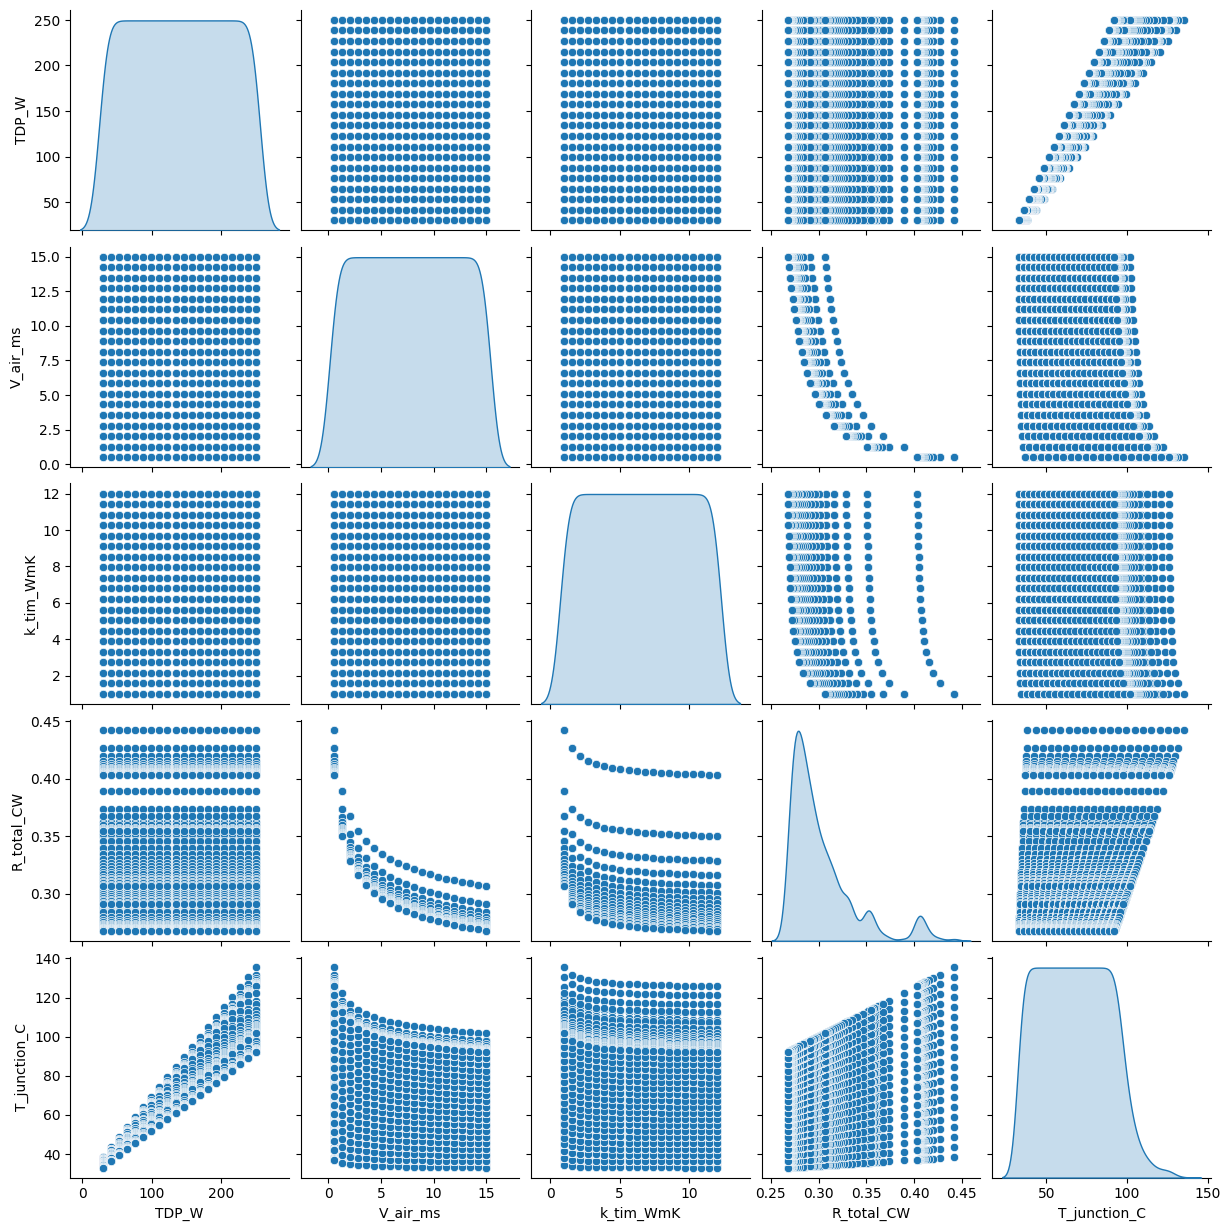

In [29]:
sns.pairplot(df, diag_kind='kde')
plt.show()

### Modelling 

In [30]:
features = ['TDP_W', 'V_air_ms', 'k_tim_WmK']
targets = ['R_total_CW', 'T_junction_C']

X = df[features]
y = df[targets]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Model 1 - Decision Tree

In [32]:
decision_trees = DecisionTreeRegressor(random_state = 42)
decision_trees.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [33]:
decision_trees_predictions = decision_trees.predict(X_test)

### Model 2 - Random Forests

In [34]:
random_forests = RandomForestRegressor(n_estimators = 200, random_state = 42)
random_forests.fit(X_train, y_train)
random_forests_predictions = random_forests.predict(X_test)

### Model Evaluations

In [35]:
def evaluate_models(y_true, y_pred, model_name):
    results = []
    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_true[target], y_pred[:, i])
        rmse = root_mean_squared_error(y_true[target], y_pred[:, i])
        r2 = r2_score(y_true[target], y_pred[:, i])
        results.append({'model': model_name, 'target': target, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return results

In [36]:
results = []
results += evaluate_models(y_test, decision_trees_predictions, 'decision_tree')
results += evaluate_models(y_test, random_forests_predictions, 'random_forests')

In [37]:
results_df = pd.DataFrame(results)
print("Model Evaluation(on Testset) ")
print(results_df.to_string(index=False))
results_df.to_csv('model_evaluation.csv', index=False)

Model Evaluation(on Testset) 
         model       target      MAE     RMSE       R2
 decision_tree   R_total_CW 0.001356 0.002513 0.994159
 decision_tree T_junction_C 0.190959 0.410270 0.999620
random_forests   R_total_CW 0.000653 0.001789 0.997040
random_forests T_junction_C 0.090629 0.281124 0.999821


In [38]:
dt_train_pred = decision_trees.predict(X_train)
print("\nDecision Tree: train vs test R2 (overfitting check)")
for i, target in enumerate(targets):
    train_r2 = r2_score(y_train[target], dt_train_pred[:, i])
    test_r2 = r2_score(y_test[target], decision_trees_predictions[:, i])
    print(f"{target}: train R2={train_r2:.5f}, test R2={test_r2:.5f}")



Decision Tree: train vs test R2 (overfitting check)
R_total_CW: train R2=1.00000, test R2=0.99416
T_junction_C: train R2=1.00000, test R2=0.99962


### Correlation Analysis(based on Basic Sensitivity)

In [39]:
corr = df[features + targets].corr()
print(corr.loc[features, targets])
corr.to_csv('correlation_matrix.csv')

             R_total_CW  T_junction_C
TDP_W     -3.236610e-15      0.967644
V_air_ms  -8.010463e-01     -0.182435
k_tim_WmK -2.189920e-01     -0.049874


### Secondary Sensitivity Check for Random Forests

In [40]:
for i, target in enumerate(targets):
    rf_single = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_single.fit(X_train, y_train[target])
    importances = dict(zip(features, rf_single.feature_importances_))
    print(f"{target}: {importances}")

R_total_CW: {'TDP_W': np.float64(8.124934912095734e-09), 'V_air_ms': np.float64(0.9235496890829769), 'k_tim_WmK': np.float64(0.07645030279208816)}
T_junction_C: {'TDP_W': np.float64(0.9358470928091194), 'V_air_ms': np.float64(0.05936551233501933), 'k_tim_WmK': np.float64(0.00478739485586134)}


### Conclusion

Comparison of Random Forests and Decision Tree Model:-


### Libraries Import

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [42]:
print(os.getcwd())

/home/chotu/Hiring_Assingments/ExpertThermal_XThermal/notebooks


### Data Exploration

In [43]:
df = pd.read_csv('grid_sweep.csv')

In [44]:
df.shape

(8000, 5)

In [45]:
df.head()

,TDP_W,V_air_ms,k_tim_WmK,R_total_CW,T_junction_C
0,30.0,0.5,1.000000,0.442180,38.265412
1,30.0,0.5,1.578947,0.426660,37.799804
2,30.0,0.5,2.157895,0.419468,37.584034
3,30.0,0.5,2.736842,0.415318,37.459551
4,30.0,0.5,3.315789,0.412618,37.378539


In [46]:
df.describe()

,TDP_W,V_air_ms,k_tim_WmK,R_total_CW,T_junction_C
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,140.000000,7.750000,6.500000,0.302312,67.323750
std,66.771641,4.400858,3.338582,0.033936,20.860878
min,30.000000,0.500000,1.000000,0.267846,33.035373
25%,85.000000,4.125000,3.750000,0.278845,49.498570
50%,140.000000,7.750000,6.500000,0.291624,66.878747
75%,195.000000,11.375000,9.250000,0.313298,84.225791
max,250.000000,15.000000,12.000000,0.442180,135.545101


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TDP_W         8000 non-null   float64
 1   V_air_ms      8000 non-null   float64
 2   k_tim_WmK     8000 non-null   float64
 3   R_total_CW    8000 non-null   float64
 4   T_junction_C  8000 non-null   float64
dtypes: float64(5)
memory usage: 312.6 KB


In [48]:
df.corr()

,TDP_W,V_air_ms,k_tim_WmK,R_total_CW,T_junction_C
TDP_W,1.000000e+00,-4.186850e-15,7.931234e-16,-3.236610e-15,0.967644
V_air_ms,-4.186850e-15,1.000000e+00,-7.617731e-18,-8.010463e-01,-0.182435
k_tim_WmK,7.931234e-16,-7.617731e-18,1.000000e+00,-2.189920e-01,-0.049874
R_total_CW,-3.236610e-15,-8.010463e-01,-2.189920e-01,1.000000e+00,0.227746
T_junction_C,9.676439e-01,-1.824349e-01,-4.987449e-02,2.277458e-01,1.000000


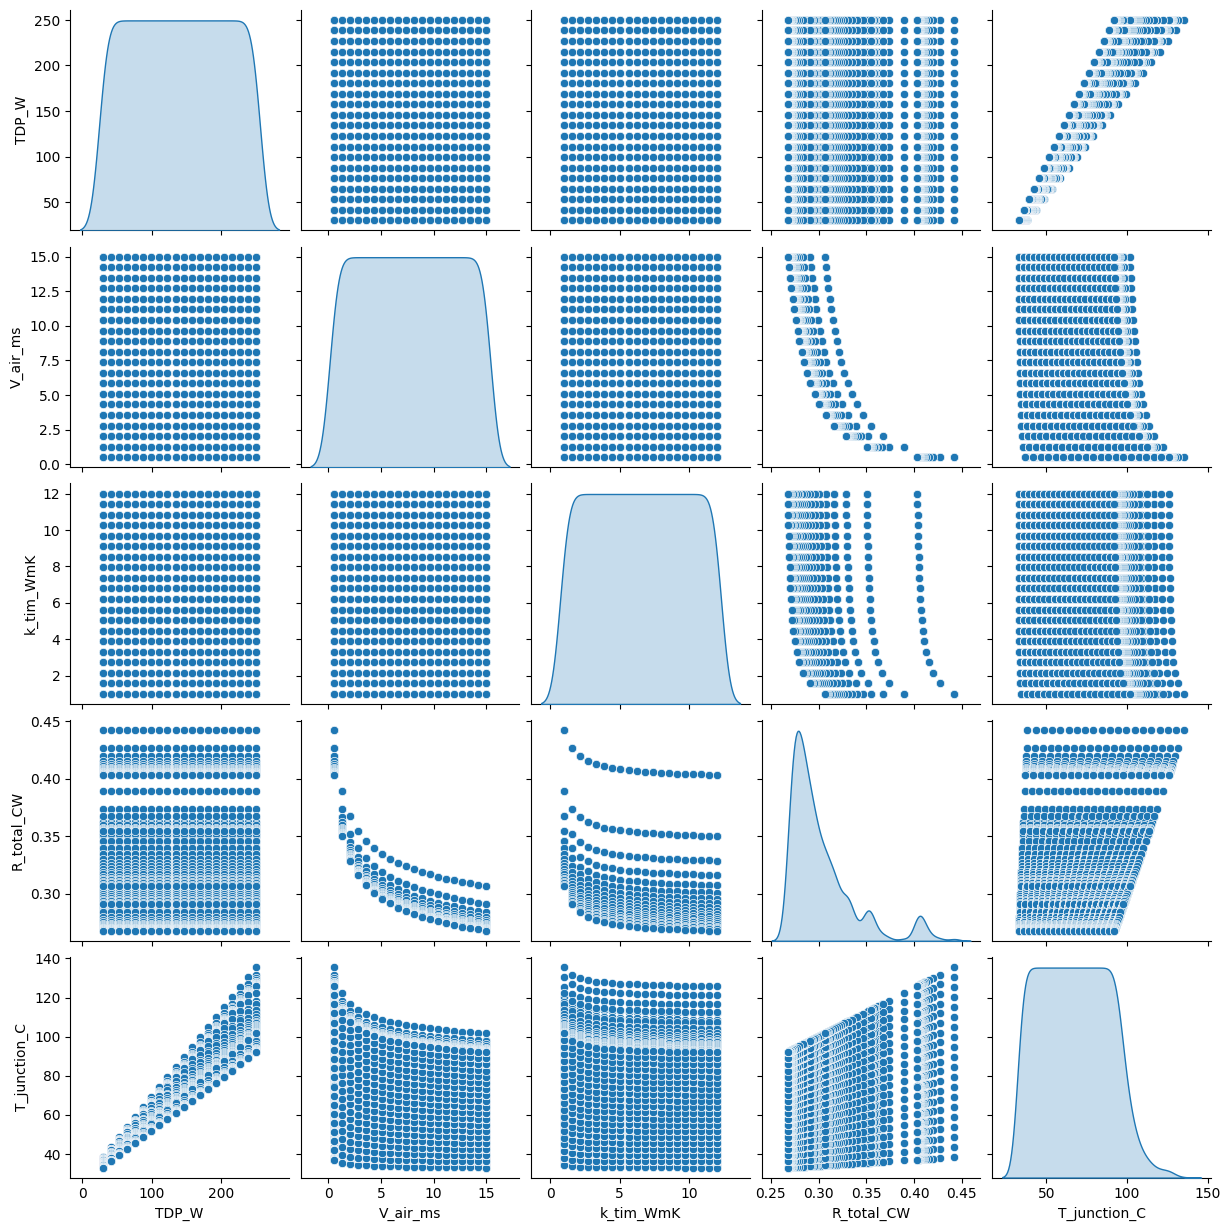

In [49]:
sns.pairplot(df, diag_kind='kde')
plt.show()

### Modelling 

In [50]:
features = ['TDP_W', 'V_air_ms', 'k_tim_WmK']
targets = ['R_total_CW', 'T_junction_C']

X = df[features]
y = df[targets]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Model 1 - Decision Tree

In [52]:
decision_trees = DecisionTreeRegressor(random_state = 42)
decision_trees.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [53]:
decision_trees_predictions = decision_trees.predict(X_test)

### Model 2 - Random Forests

In [54]:
random_forests = RandomForestRegressor(n_estimators = 200, random_state = 42)
random_forests.fit(X_train, y_train)
random_forests_predictions = random_forests.predict(X_test)

### Model Evaluations

In [55]:
def evaluate_models(y_true, y_pred, model_name):
    results = []
    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_true[target], y_pred[:, i])
        rmse = root_mean_squared_error(y_true[target], y_pred[:, i])
        r2 = r2_score(y_true[target], y_pred[:, i])
        results.append({'model': model_name, 'target': target, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return results

In [56]:
results = []
results += evaluate_models(y_test, decision_trees_predictions, 'decision_tree')
results += evaluate_models(y_test, random_forests_predictions, 'random_forests')

In [57]:
results_df = pd.DataFrame(results)
print("Model Evaluation(on Testset) ")
print(results_df.to_string(index=False))
results_df.to_csv('model_evaluation.csv', index=False)

Model Evaluation(on Testset) 
         model       target      MAE     RMSE       R2
 decision_tree   R_total_CW 0.001356 0.002513 0.994159
 decision_tree T_junction_C 0.190959 0.410270 0.999620
random_forests   R_total_CW 0.000653 0.001789 0.997040
random_forests T_junction_C 0.090629 0.281124 0.999821


In [58]:
dt_train_pred = decision_trees.predict(X_train)
print("\nDecision Tree: train vs test R2 (overfitting check)")
for i, target in enumerate(targets):
    train_r2 = r2_score(y_train[target], dt_train_pred[:, i])
    test_r2 = r2_score(y_test[target], decision_trees_predictions[:, i])
    print(f"{target}: train R2={train_r2:.5f}, test R2={test_r2:.5f}")



Decision Tree: train vs test R2 (overfitting check)
R_total_CW: train R2=1.00000, test R2=0.99416
T_junction_C: train R2=1.00000, test R2=0.99962


### Correlation Analysis(based on Basic Sensitivity)

In [59]:
corr = df[features + targets].corr()
print(corr.loc[features, targets])
corr.to_csv('correlation_matrix.csv')

             R_total_CW  T_junction_C
TDP_W     -3.236610e-15      0.967644
V_air_ms  -8.010463e-01     -0.182435
k_tim_WmK -2.189920e-01     -0.049874


### Secondary Sensitivity Check for Random Forests

In [60]:
for i, target in enumerate(targets):
    rf_single = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_single.fit(X_train, y_train[target])
    importances = dict(zip(features, rf_single.feature_importances_))
    print(f"{target}: {importances}")

R_total_CW: {'TDP_W': np.float64(8.124934912095734e-09), 'V_air_ms': np.float64(0.9235496890829769), 'k_tim_WmK': np.float64(0.07645030279208816)}
T_junction_C: {'TDP_W': np.float64(0.9358470928091194), 'V_air_ms': np.float64(0.05936551233501933), 'k_tim_WmK': np.float64(0.00478739485586134)}


### Conclusion

Comparison of Random Forests and Decision Tree Model:-

We can observe that Random Forests out has outperformed the Single Decision Tree on both the targets across every metric(roughly half the test MAE/RMSE). Decision Tree shows the small overfitting gap(R2=1.0 for train VS R2~0.994-0.9996 for test), and Random Forest reduces by averaging over many trees. Given that the dataset generated is dense, noise free grid over smooth physical function. Even though this gap is modest than dramatic, ensembling still holds true.




Sensitivity Findings:-

The Correlation analysis and the Random Forst Feature importances agree on two dominant drivers.
R_total is driven by V_air almost entirely(given corr = -0.80, RF importance = 92%), it is consistent with the convective resistance termn dominating the heat sink's total resistance.
T_junction is driven by TDP(corr = 0.97, RF importance = 94%), consistent with T_j being T_ambient plus TDP times total resistance.
k_tim has secondary but real effect on R_total and negligible effect on T_j.



Final Conclusion Based on above work

If our goal is to minimize the Junction Temperature, increasing the airflow which is V_air is the most effective lever on the thermal resistance. While TDP is largely a fixed constraint set by the processor itself rather than something to optimze.